# II. RECOMBINATION

The Saha equation describes the state of thermodynamic equilibrium for the reaction $e^- + p^+ <-> H \gamma $, assuming that the interactions are much faster than the expansion rate of the universe; every time an atom is created, another is immediately destroyed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import odeint
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

In [7]:
# Costants
B_H = 13.6  # eV
m_e = 0.511e6  # eV 
heta = 6e-10
zeta3 = 1.202
T0 = 2.353e-4  # eV
Lambda = 4000

Temperature of recombination: T_recomb = 0.295 eV


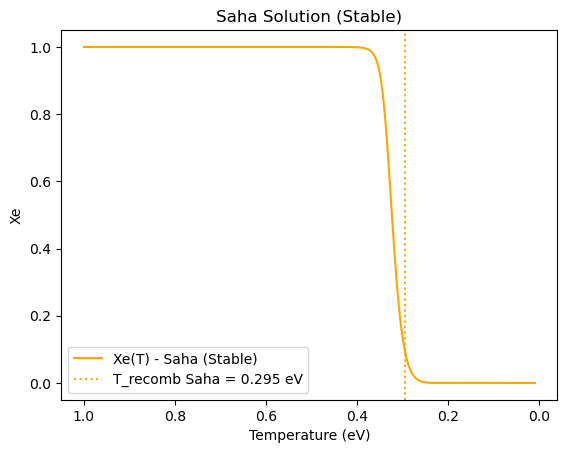

In [8]:
#  SAHA SOLUTION

def saha_rhs(T):
    # If T is very low, exp(B_H/T) is infinite.
    arg = B_H / T
    if arg > 600: # np.exp(700) is approximately inf
        return 1e300 # A very large number but not 'inf'

    return (2 * zeta3 * heta / np.pi**2 ) * ((2 * np.pi * T / m_e) ** (3/2)) * np.exp(arg)

def saha_quadratic_solver(T):
    # Solve the equation of Saha using the analytical quadratic solution.
    rhs = saha_rhs(T)

    # If rhs is enormous (low T), the solution approximates to 1/sqrt(rhs)
    if rhs > 1e18:
        return 1.0 / np.sqrt(rhs)

    # Quadratic solution: rhs*Xe^2 + Xe - 1 = 0
    Xe_sol = (-1.0 + np.sqrt(1.0 + 4.0 * rhs)) / (2.0 * rhs)
    return Xe_sol

# Computation of Xe(T) for Saha
T_arr = np.linspace(0.01, 1.0, 300)

# Vectorize the existing function
v_saha_solver = np.vectorize(saha_quadratic_solver)

# Apply the function directly to the entire array
Xe_array = v_saha_solver(T_arr)
recomb_index_saha = np.argmin(np.abs(Xe_array - 0.1)) # Index where Xe = 0.1 so to find T_recomb
T_recomb = T_arr[recomb_index_saha]

# Solution Plot
plt.figure()
plt.plot(T_arr, Xe_arr, label='Xe(T) - Saha (Stable)', color='orange')
plt.axvline(T_recomb, color='orange', linestyle=':',
            label=f'T_recomb Saha = {T_recomb:.3f} eV')
plt.xlabel('Temperature (eV)')
plt.ylabel('Xe')
plt.title('Saha Solution (Stable)')
plt.legend()
plt.gca().invert_xaxis()

print(f"Temperature of recombination: T_recomb = {T_recomb:.3f} eV")



At high temperatures ($T>0,4 eV$) $X_e = 1$, the Universe looks like completely ionized plasma. Instead, at $T ≈ 0,3 eV$ the curve drops rapidly as cooling allows electrons and protons to combine into hydrogen.

Considering the expansion of the universe, the temperature drops and energetic photons capable of destroying hydrogen become increasingly rare; the interaction rate plummets and becomes slower than the expansion rate. The system falls out of equilibrium, and the Boltzmann equation is used.

Temperature of recombination: Tem_recomb = 0.278 eV


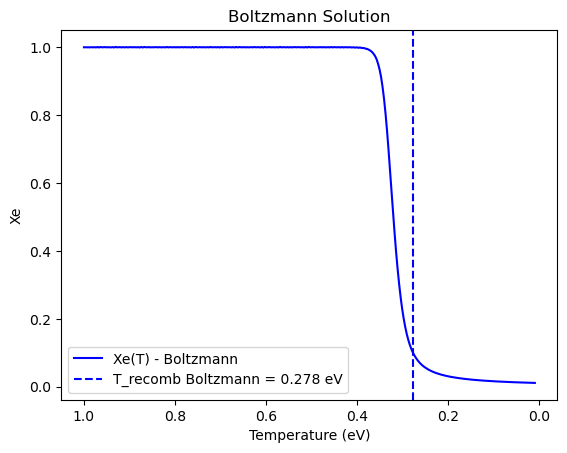

In [4]:

# BOLTZMANN SOLUTION

# Interpolation of Saha solution
Xe_eq_interp = interp1d(T_arr, Xe_arr, kind='linear', fill_value="extrapolate") # creates a function that interpolates the Saha solution for any temperature T
# Lambda Parameter for the Boltzmann equation
Lambda = 4000 # quantifies the velocity with which the recombination reactions try to bring the system to equilibrium with respect to the expansion rate of the universe

# Boltzmann equation corrected with physical limits
def boltzmann_rhs(T, Xe):
    Xe_eq_T = Xe_eq_interp(T)
    # Protection for very small values
    if Xe < 1e-10: Xe = 1e-10

    dXe_dT = (Lambda / B_H) * (Xe**2 - Xe_eq_T**2)

    # Constraint
    if abs(Xe - Xe_eq_T) < 1e-6:
        return 0.0
    return dXe_dT

# Integration
T_rev = T_arr[::-1] # invert array temperature for integration from high to low T
sol = solve_ivp(boltzmann_rhs, [T_rev[0], T_rev[-1]], [1.0], t_eval=T_rev, method='RK45')

# Restore ascending order of T
T_out = sol.t[::-1]
Xe_out = sol.y[0][::-1]

# Finds temperature of recombination (Boltzmann)
recomb_index_boltzmann = np.argmin(np.abs(Xe_out - 0.1))
Tem_recomb = T_out[recomb_index_boltzmann]

# Plot the Boltzmann solution
plt.figure()
plt.plot(T_out, Xe_out, label='Xe(T) - Boltzmann', color='blue')
plt.axvline(Tem_recomb, color='blue', linestyle='--',
            label=f'T_recomb Boltzmann = {Tem_recomb:.3f} eV')
plt.xlabel('Temperature (eV)')
plt.ylabel('Xe')
plt.title('Boltzmann Solution')
plt.legend()
plt.gca().invert_xaxis()


print(f"Temperature of recombination: Tem_recomb = {Tem_recomb:.3f} eV")



This trend is similar to that of the Saha equation, but it accounts for the fact that the universe is expanding, so everything occurs at lower temperatures.

Temperature of recombination Saha (Stable): T_recomb = 0.295 eV
Temperature of recombination Boltzmann: Tem_recomb = 0.278 eV


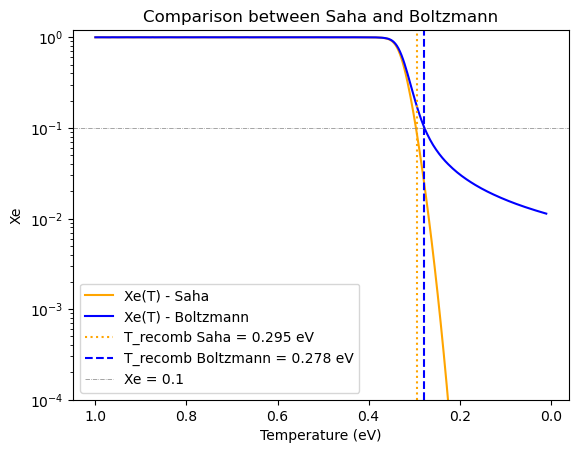

In [5]:
# COMPARISON PLOT

plt.figure()
# Saha Plot
plt.plot(T_arr, Xe_arr, label='Xe(T) - Saha ', color='orange')
# Boltzmann Plot
plt.plot(T_out, Xe_out, label='Xe(T) - Boltzmann', color='blue')

# Vertical lines
plt.axvline(T_recomb, color='orange', linestyle=':',
            label=f'T_recomb Saha = {T_recomb:.3f} eV')
plt.axvline(Tem_recomb, color='blue', linestyle='--',
            label=f'T_recomb Boltzmann = {Tem_recomb:.3f} eV')
plt.axhline(0.1, color='gray', linestyle='-.', linewidth=0.5, label='Xe = 0.1')

plt.xlabel('Temperature (eV)')
plt.ylabel('Xe')
plt.title('Comparison between Saha and Boltzmann')
plt.legend()
plt.gca().invert_xaxis()
plt.ylim(1e-4, 1.2)
plt.yscale('log')


print(f"Temperature of recombination Saha (Stable): T_recomb = {T_recomb:.3f} eV")
print(f"Temperature of recombination Boltzmann: Tem_recomb = {Tem_recomb:.3f} eV")


When $ \Gamma >> H  $ the two trends perfectly overlap; however, when $T \approx 0.3 \text{ eV}$, both curves drop rapidly, but the Boltzmann curve is slightly delayed (the expansion of the Universe slows down the recombination process). During the freeze-out, the Saha curve continues to plummet exponentially toward zero, whereas the Boltzmann curve stops falling and freezes at a constant value.

Redshift of recombination Saha (Stable): z_recomb = 1252
Redshift of recombination Boltzmann: z_recomb = 1181


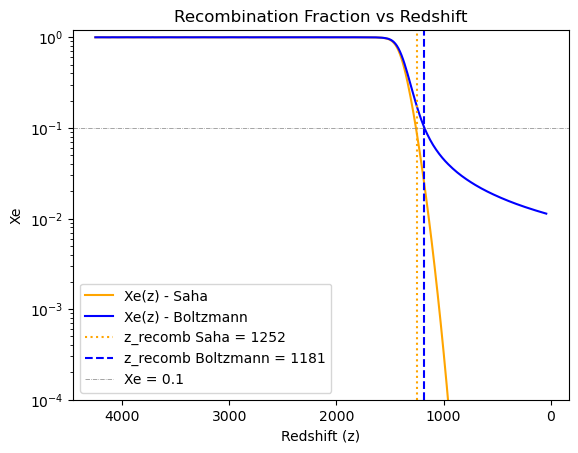

In [6]:
# REDSHIFT COMPUTATION AND PLOT

# Convert temperature to redshift
z_arr = (T_arr / T0) - 1
z_out = (T_out / T0) - 1

# Find redshift of recombination
z_recomb_saha = (T_recomb / T0) - 1
z_recomb_boltz = (Tem_recomb / T0) - 1

# Redshift Plot
plt.figure()
# Saha Plot
plt.plot(z_arr, Xe_arr, label='Xe(z) - Saha', color='orange')
# Boltzmann Plot
plt.plot(z_out, Xe_out, label='Xe(z) - Boltzmann', color='blue')

# Vertical lines
plt.axvline(z_recomb_saha, color='orange', linestyle=':', 
            label=f'z_recomb Saha = {z_recomb_saha:.0f}')
plt.axvline(z_recomb_boltz, color='blue', linestyle='--', 
            label=f'z_recomb Boltzmann = {z_recomb_boltz:.0f}')
plt.axhline(0.1, color='gray', linestyle='-.', linewidth=0.5, label='Xe = 0.1')

plt.xlabel('Redshift (z)')
plt.ylabel('Xe')
plt.title('Recombination Fraction vs Redshift')
plt.legend()
plt.gca().invert_xaxis()
plt.ylim(1e-4, 1.2)
plt.yscale('log')

print(f"Redshift of recombination Saha (Stable): z_recomb = {z_recomb_saha:.0f}")
print(f"Redshift of recombination Boltzmann: z_recomb = {z_recomb_boltz:.0f}")